In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import pandas as pd
import matplotlib.pyplot as plt
import folium
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

In [2]:
df_a = pd.read_csv("InstallationDatasetC+A/Arkansas_full_clean.csv")
df_c =pd.read_csv("InstallationDatasetC+A/California_full_clean.csv")

In [3]:
#Californie
df_a.info()
df_a.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9218 entries, 0 to 9217
Columns: 367 entries, B11_T0 to crop_name
dtypes: float64(365), int64(1), object(1)
memory usage: 25.8+ MB


,B11_T0,B11_T1,B11_T10,B11_T11,B11_T12,B11_T13,B11_T14,B11_T15,B11_T16,B11_T17,...,B8_T7,B8_T8,B8_T9,aspect,crop_label,elevation,latitude,longitude,slope,crop_name
0,3758.0,4060.0,6824.0,4118.0,5594.0,5586.0,6487.0,0.0,4378.0,3828.5,...,3207.0,3220.0,3489.0,129.525467,5,62.0,34.403047,-91.417880,1.457040,Soybeans
1,3185.5,3591.5,6134.0,3803.0,6019.5,5473.0,5635.5,3500.5,2872.0,2611.0,...,3567.0,3024.0,2976.0,67.556168,1,58.0,34.296665,-91.354877,2.427947,Corn
2,3063.0,3285.5,3038.0,2816.5,2981.0,3013.5,3468.0,0.0,3210.5,3494.0,...,3808.0,3793.0,3913.0,218.912735,5,63.0,34.327085,-91.512739,3.571335,Soybeans
3,2196.0,3534.0,5513.5,3020.0,3690.5,5059.0,6081.5,0.0,5417.0,1875.0,...,2834.0,3135.0,4868.0,180.000000,3,76.0,35.744828,-90.708118,0.927410,Rice
4,3268.0,3586.0,4803.0,3734.5,0.0,0.0,4277.0,0.0,5297.0,6177.5,...,0.0,3542.0,3498.0,129.085922,2,64.0,35.681737,-90.577141,1.470752,Cotton


In [4]:

df_c.info()
df_c.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 367 entries, B11_T0 to crop_name
dtypes: float64(365), int64(1), object(1)
memory usage: 28.0+ MB


,B11_T0,B11_T1,B11_T10,B11_T11,B11_T12,B11_T13,B11_T14,B11_T15,B11_T16,B11_T17,...,B8_T7,B8_T8,B8_T9,aspect,crop_label,elevation,latitude,longitude,slope,crop_name
0,3115.0,4850.5,3541.0,3545.5,3559.0,3663.5,3795.0,3862.0,3923.5,3903.0,...,3531.0,3871.0,4251.5,270.0,75,63.0,36.985456,-120.244224,3.479089,Almonds
1,3010.0,4341.0,4419.5,4116.0,4093.5,4109.0,4069.0,4308.0,4304.5,4285.0,...,2774.0,3703.0,4121.0,180.0,69,56.0,36.806455,-120.236123,2.780288,Grapes
2,5442.0,5391.5,5328.0,4944.5,4538.5,4063.0,3496.0,3168.5,2996.5,2934.0,...,0.0,4154.0,4314.0,270.0,54,57.0,36.593757,-120.110445,4.610818,Others
3,2816.0,3150.0,2790.5,2921.5,2953.0,3062.0,3273.0,3197.0,3269.0,3260.0,...,3549.5,3756.5,0.0,90.0,75,39.0,38.589882,-121.948171,2.371869,Almonds
4,2606.0,3128.0,3294.5,2956.5,3423.0,3498.5,3334.5,3499.5,3542.5,3498.5,...,2676.0,3034.0,3330.0,270.0,75,8.0,38.463725,-121.715547,3.549057,Almonds


In [5]:
#ordonner les colonnes
nouvel_ordre = [
    'B2_T0','B3_T0','B4_T0','B5_T0','B6_T0','B7_T0','B8_T0','B8A_T0','B11_T0','B12_T0',
    'B2_T1','B3_T1','B4_T1','B5_T1','B6_T1','B7_T1','B8_T1','B8A_T1','B11_T1','B12_T1',
    'B2_T2','B3_T2','B4_T2','B5_T2','B6_T2','B7_T2','B8_T2','B8A_T2','B11_T2','B12_T2',
    'B2_T3','B3_T3','B4_T3','B5_T3','B6_T3','B7_T3','B8_T3','B8A_T3','B11_T3','B12_T3',
    'B2_T4','B3_T4','B4_T4','B5_T4','B6_T4','B7_T4','B8_T4','B8A_T4','B11_T4','B12_T4',
    'B2_T5','B3_T5','B4_T5','B5_T5','B6_T5','B7_T5','B8_T5','B8A_T5','B11_T5','B12_T5',
    'B2_T6','B3_T6','B4_T6','B5_T6','B6_T6','B7_T6','B8_T6','B8A_T6','B11_T6','B12_T6',
    'B2_T7','B3_T7','B4_T7','B5_T7','B6_T7','B7_T7','B8_T7','B8A_T7','B11_T7','B12_T7',
    'B2_T8','B3_T8','B4_T8','B5_T8','B6_T8','B7_T8','B8_T8','B8A_T8','B11_T8','B12_T8',
    'B2_T9','B3_T9','B4_T9','B5_T9','B6_T9','B7_T9','B8_T9','B8A_T9','B11_T9','B12_T9',
    'B2_T10','B3_T10','B4_T10','B5_T10','B6_T10','B7_T10','B8_T10','B8A_T10','B11_T10','B12_T10',
    'B2_T11','B3_T11','B4_T11','B5_T11','B6_T11','B7_T11','B8_T11','B8A_T11','B11_T11','B12_T11',
    'B2_T12','B3_T12','B4_T12','B5_T12','B6_T12','B7_T12','B8_T12','B8A_T12','B11_T12','B12_T12',
    'B2_T13','B3_T13','B4_T13','B5_T13','B6_T13','B7_T13','B8_T13','B8A_T13','B11_T13','B12_T13',
    'B2_T14','B3_T14','B4_T14','B5_T14','B6_T14','B7_T14','B8_T14','B8A_T14','B11_T14','B12_T14',
    'B2_T15','B3_T15','B4_T15','B5_T15','B6_T15','B7_T15','B8_T15','B8A_T15','B11_T15','B12_T15',
    'B2_T16','B3_T16','B4_T16','B5_T16','B6_T16','B7_T16','B8_T16','B8A_T16','B11_T16','B12_T16',
    'B2_T17','B3_T17','B4_T17','B5_T17','B6_T17','B7_T17','B8_T17','B8A_T17','B11_T17','B12_T17',
    'B2_T18','B3_T18','B4_T18','B5_T18','B6_T18','B7_T18','B8_T18','B8A_T18','B11_T18','B12_T18',
    'B2_T19','B3_T19','B4_T19','B5_T19','B6_T19','B7_T19','B8_T19','B8A_T19','B11_T19','B12_T19',
    'B2_T20','B3_T20','B4_T20','B5_T20','B6_T20','B7_T20','B8_T20','B8A_T20','B11_T20','B12_T20',
    'B2_T21','B3_T21','B4_T21','B5_T21','B6_T21','B7_T21','B8_T21','B8A_T21','B11_T21','B12_T21',
    'B2_T22','B3_T22','B4_T22','B5_T22','B6_T22','B7_T22','B8_T22','B8A_T22','B11_T22','B12_T22',
    'B2_T23','B3_T23','B4_T23','B5_T23','B6_T23','B7_T23','B8_T23','B8A_T23','B11_T23','B12_T23',
    'B2_T24','B3_T24','B4_T24','B5_T24','B6_T24','B7_T24','B8_T24','B8A_T24','B11_T24','B12_T24',
    'B2_T25','B3_T25','B4_T25','B5_T25','B6_T25','B7_T25','B8_T25','B8A_T25','B11_T25','B12_T25',
    'B2_T26','B3_T26','B4_T26','B5_T26','B6_T26','B7_T26','B8_T26','B8A_T26','B11_T26','B12_T26',
    'B2_T27','B3_T27','B4_T27','B5_T27','B6_T27','B7_T27','B8_T27','B8A_T27','B11_T27','B12_T27',
    'B2_T28','B3_T28','B4_T28','B5_T28','B6_T28','B7_T28','B8_T28','B8A_T28','B11_T28','B12_T28',
    'B2_T29','B3_T29','B4_T29','B5_T29','B6_T29','B7_T29','B8_T29','B8A_T29','B11_T29','B12_T29',
    'B2_T30','B3_T30','B4_T30','B5_T30','B6_T30','B7_T30','B8_T30','B8A_T30','B11_T30','B12_T30',
    'B2_T31','B3_T31','B4_T31','B5_T31','B6_T31','B7_T31','B8_T31','B8A_T31','B11_T31','B12_T31',
    'B2_T32','B3_T32','B4_T32','B5_T32','B6_T32','B7_T32','B8_T32','B8A_T32','B11_T32','B12_T32',
    'B2_T33','B3_T33','B4_T33','B5_T33','B6_T33','B7_T33','B8_T33','B8A_T33','B11_T33','B12_T33',
    'B2_T34','B3_T34','B4_T34','B5_T34','B6_T34','B7_T34','B8_T34','B8A_T34','B11_T34','B12_T34',
    'B2_T35','B3_T35','B4_T35','B5_T35','B6_T35','B7_T35','B8_T35','B8A_T35','B11_T35','B12_T35',
    'crop_label','latitude','longitude','aspect','elevation','slope','crop_name'
]
df_a=df_a[nouvel_ordre]
df_c=df_c[nouvel_ordre]

In [6]:
df_a.head()


,B2_T0,B3_T0,B4_T0,B5_T0,B6_T0,B7_T0,B8_T0,B8A_T0,B11_T0,B12_T0,...,B8A_T35,B11_T35,B12_T35,crop_label,latitude,longitude,aspect,elevation,slope,crop_name
0,1836.0,2042.0,2412.0,2616.0,2753.0,2920.0,3186.0,3215.0,3758.0,3099.0,...,3227.0,3578.0,2796.0,5,34.403047,-91.417880,129.525467,62.0,1.457040,Soybeans
1,1647.0,1908.0,2099.0,2438.0,2752.0,2925.5,3122.0,3092.0,3185.5,2471.0,...,3093.5,2923.5,2274.0,1,34.296665,-91.354877,67.556168,58.0,2.427947,Corn
2,1655.0,1878.5,2135.0,2279.5,2724.5,2947.5,3587.0,3190.0,3063.0,2307.0,...,3495.5,3018.5,2285.0,5,34.327085,-91.512739,218.912735,63.0,3.571335,Soybeans
3,1817.5,1984.0,2207.0,2458.5,2499.5,2613.0,2731.0,2754.5,2196.0,1753.5,...,3044.5,2978.5,2389.0,3,35.744828,-90.708118,180.000000,76.0,0.927410,Rice
4,1456.0,1630.0,1704.0,2031.0,2475.0,2684.0,3062.0,2971.0,3268.0,2510.0,...,3991.0,3389.0,2462.0,2,35.681737,-90.577141,129.085922,64.0,1.470752,Cotton


In [7]:
df_c.head()

,B2_T0,B3_T0,B4_T0,B5_T0,B6_T0,B7_T0,B8_T0,B8A_T0,B11_T0,B12_T0,...,B8A_T35,B11_T35,B12_T35,crop_label,latitude,longitude,aspect,elevation,slope,crop_name
0,1588.5,1731.0,1732.0,2173.0,2406.5,2584.5,2733.0,2789.5,3115.0,2651.5,...,0.0,0.0,0.0,75,36.985456,-120.244224,270.0,63.0,3.479089,Almonds
1,1776.0,1888.0,2068.0,2113.0,2184.0,2234.0,2466.0,2390.0,3010.0,2775.0,...,0.0,0.0,0.0,69,36.806455,-120.236123,180.0,56.0,2.780288,Grapes
2,2597.0,2900.0,3313.0,3498.5,3519.5,3750.5,3945.0,3918.0,5442.0,5144.5,...,0.0,0.0,0.0,54,36.593757,-120.110445,270.0,57.0,4.610818,Others
3,1330.0,1511.0,1778.0,1983.0,2200.0,2351.0,2489.0,2585.0,2816.0,2294.0,...,0.0,0.0,0.0,75,38.589882,-121.948171,90.0,39.0,2.371869,Almonds
4,1258.0,1487.0,1587.0,1871.0,2042.0,2130.0,2226.0,2284.0,2606.0,2244.0,...,0.0,0.0,0.0,75,38.463725,-121.715547,270.0,8.0,3.549057,Almonds


In [8]:
df_a['crop_name'].value_counts()



crop_name
Soybeans    4873
Rice        1743
Corn        1623
Cotton       730
Others       249
Name: count, dtype: int64

In [9]:
df_c['crop_name'].value_counts()


crop_name
Others        3054
Almonds       2839
Grapes        2080
Pistachios     927
Alfalfa        831
Rice           269
Name: count, dtype: int64

In [10]:
df_a['crop_label'].value_counts()


crop_label
5      4873
3      1743
1      1623
2       730
26       72
190      31
24       30
4        27
121      25
122      19
61       16
37        8
123       8
176       5
111       2
59        2
10        1
124       1
74        1
195       1
Name: count, dtype: int64

In [11]:
df_c['crop_label'].value_counts()


crop_label
75     2839
69     2080
204     927
36      831
24      828
54      561
76      442
3       269
6       235
1       201
72       98
2        93
61       85
28       72
21       58
77       42
66       38
176      36
121      33
122      29
37       24
4        21
42       17
195      15
68       14
23       14
205       9
67        9
220       9
22        8
58        7
123       7
71        7
211       5
225       5
208       4
190       3
111       3
33        2
74        2
228       2
152       2
217       1
212       1
131       1
226       1
57        1
43        1
229       1
216       1
47        1
227       1
124       1
237       1
218       1
48        1
Name: count, dtype: int64

In [13]:
map = folium.Map(location=[df_a['latitude'].mean(), df_a['longitude'].mean()], zoom_start=10)
for i in range(len(df_a)):
    folium.CircleMarker(
        location=[df_a.iloc[i]['latitude'],df_a.iloc[i]['longitude']],
        radius=2
    ).add_to(map)

map.save("map.html") 
map = folium.Map(location=[df_a['latitude'].mean(), df_a['longitude'].mean()], zoom_start=10)
for i in range(len(df_a)):
    folium.CircleMarker(
        location=[df_a.iloc[i]['latitude'],df_a.iloc[i]['longitude']],
        radius=2
    ).add_to(map)

map.save("map.html") 

In [ ]:
#Arkansas

In [14]:
print(df_a.columns.tolist())


['B2_T0', 'B3_T0', 'B4_T0', 'B5_T0', 'B6_T0', 'B7_T0', 'B8_T0', 'B8A_T0', 'B11_T0', 'B12_T0', 'B2_T1', 'B3_T1', 'B4_T1', 'B5_T1', 'B6_T1', 'B7_T1', 'B8_T1', 'B8A_T1', 'B11_T1', 'B12_T1', 'B2_T2', 'B3_T2', 'B4_T2', 'B5_T2', 'B6_T2', 'B7_T2', 'B8_T2', 'B8A_T2', 'B11_T2', 'B12_T2', 'B2_T3', 'B3_T3', 'B4_T3', 'B5_T3', 'B6_T3', 'B7_T3', 'B8_T3', 'B8A_T3', 'B11_T3', 'B12_T3', 'B2_T4', 'B3_T4', 'B4_T4', 'B5_T4', 'B6_T4', 'B7_T4', 'B8_T4', 'B8A_T4', 'B11_T4', 'B12_T4', 'B2_T5', 'B3_T5', 'B4_T5', 'B5_T5', 'B6_T5', 'B7_T5', 'B8_T5', 'B8A_T5', 'B11_T5', 'B12_T5', 'B2_T6', 'B3_T6', 'B4_T6', 'B5_T6', 'B6_T6', 'B7_T6', 'B8_T6', 'B8A_T6', 'B11_T6', 'B12_T6', 'B2_T7', 'B3_T7', 'B4_T7', 'B5_T7', 'B6_T7', 'B7_T7', 'B8_T7', 'B8A_T7', 'B11_T7', 'B12_T7', 'B2_T8', 'B3_T8', 'B4_T8', 'B5_T8', 'B6_T8', 'B7_T8', 'B8_T8', 'B8A_T8', 'B11_T8', 'B12_T8', 'B2_T9', 'B3_T9', 'B4_T9', 'B5_T9', 'B6_T9', 'B7_T9', 'B8_T9', 'B8A_T9', 'B11_T9', 'B12_T9', 'B2_T10', 'B3_T10', 'B4_T10', 'B5_T10', 'B6_T10', 'B7_T10', 'B8_T10',

In [19]:
#separer x et y
df_a_x = df_a.drop(columns=['crop_label','latitude','longitude','crop_name'])
X_a = df_a_x.values
df_a_y =df_a[['crop_name','crop_label']]
df_a_y.loc[df_a['crop_name'] == 'Others', 'crop_label'] = 0
df_a_y.loc[df_a['crop_label'] == 5, 'crop_label'] = 4
y_a = df_a_y['crop_label'].values

In [21]:
#reshape
X_time = df_a_x[[col for col in df_a_x.columns if '_T' in col]].values
X_time = X_time.reshape(-1, 36, 10)
X_static = df_a_x[['elevation', 'slope', 'aspect']].values

#normalisation
X_max = X_time.max(axis=(0, 1), keepdims=True)
X_max[X_max == 0] = 1  
X_time = X_time / X_max
X_static = X_static / X_static.max(axis=0)


In [23]:
mask_time = (X_time != 0).astype(float)


In [24]:
#Split

X_time_train, X_time_test, X_static_train, X_static_test, \
y_train, y_test, mask_train, mask_test = train_test_split(
    X_time,
    X_static,
    y_a,
    mask_time,
    test_size=0.85,
    stratify=y_a,
    random_state=42
)

X_time_train, X_time_val, X_static_train, X_static_val, \
y_train, y_val, mask_train, mask_val = train_test_split(
    X_time_train,
    X_static_train,
    y_train,
    mask_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

In [25]:
#Le CNN
def CNNBlock(x):
    shortcut = x
    dim = x.shape[-1]

    x = layers.Conv1D(filters=dim, kernel_size=3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv1D(filters=dim, kernel_size=3, padding='same')(x)
    x = layers.BatchNormalization()(x)

    x = layers.Add()([x, shortcut])  # shortcut connection
    x = layers.ReLU()(x)
    return x

In [26]:
#Transformer
def TransformerBlock(x, num_heads=5):
    dim = x.shape[-1]

    # Multi-head attention
    attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=dim)(x, x)
    x = layers.Add()([x, attn])
    x = layers.LayerNormalization()(x)

    # Feed Forward
    ff = layers.Dense(dim, activation='relu')(x)
    ff = layers.Dense(dim)(ff)

    x = layers.Add()([x, ff])
    x = layers.LayerNormalization()(x)

    return x

In [27]:
def ALPE(x, mask):
    

    x = layers.Multiply()([x, mask])

    x = layers.Conv1D(filters=x.shape[-1], kernel_size=3, padding='same')(x)

    # Attention simple (approximation ECA)
    weights = layers.GlobalAveragePooling1D()(x)
    weights = layers.Dense(x.shape[-1], activation='sigmoid')(weights)
    weights = layers.Reshape((1, x.shape[-1]))(weights)

    x = layers.Multiply()([x, weights])

    return x

In [28]:
def CTFusion(x):
    cnn_out = CNNBlock(x)
    trans_out = TransformerBlock(x)
    fused = layers.Concatenate()([cnn_out, trans_out])  # (batch, T, 20)
    fused = layers.Dense(x.shape[-1])(fused)            # projection → (batch, T, 10)
    return fused

In [47]:
def build_MCTNet(input_shape=(36, 10), static_shape=(3,), num_classes=5):

    # =========================
    # INPUT TIME SERIES
    # =========================
    inputs = tf.keras.Input(shape=input_shape)
    mask = tf.keras.Input(shape=input_shape)

    x = ALPE(inputs, mask)

    x = CTFusion(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = CTFusion(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = CTFusion(x)

    x = layers.GlobalMaxPooling1D()(x)

    # =========================
    # TOPOGRAPHY (NEW ONLY)
    # =========================
    inputs_static = tf.keras.Input(shape=static_shape)

    x_static = layers.Dense(16, activation='relu')(inputs_static)

    # =========================
    # FUSION (ONLY ADDITION)
    # =========================
    x = layers.Concatenate()([x, x_static])

    # =========================
    # CLASSIFIER (UNCHANGED LOGIC)
    # =========================
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(
        inputs=[inputs, mask, inputs_static],
        outputs=outputs
    )

    return model


In [48]:
model = build_MCTNet()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 36, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_12      │ (None, 36, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_11         │ (None, 36, 10)    │          0 │ input_layer_11[0… │
│ (Multiply)          │                   │            │ input_layer_12[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_22 (Conv1D)  │ (None, 36, 10)    │        310 │ multiply_11[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 10)        │          0 │ conv1d_22[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_37 (Dense)    │ (None, 10)        │        110 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_4 (Reshape) │ (None, 1, 10)     │          0 │ dense_37[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_12         │ (None, 36, 10)    │          0 │ conv1d_22[0][0],  │
│ (Multiply)          │                   │            │ reshape_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_23 (Conv1D)  │ (None, 36, 10)    │        310 │ multiply_12[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 36, 10)    │      2,160 │ multiply_12[0][0… │
│ (MultiHeadAttentio… │                   │            │ multiply_12[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 36, 10)    │         40 │ conv1d_23[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_28 (Add)        │ (None, 36, 10)    │          0 │ multiply_12[0][0… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_18 (ReLU)     │ (None, 36, 10)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 36, 10)    │         20 │ add_28[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_24 (Conv1D)  │ (None, 36, 10)    │        310 │ re_lu_18[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_38 (Dense)    │ (None, 36, 10)    │        110 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 36, 10)    │         40 │ conv1d_24[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_39 (Dense)    │ (None, 36, 10)    │        110 │ dense_38[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_27 (Add)        │ (None, 36, 10)    │          0 │ batch_normalizat… │
│                     │                   │            │ multiply_12[0][0] │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 10,609 (41.44 KB)

 Trainable params: 10,489 (40.97 KB)

 Non-trainable params: 120 (480.00 B)

In [49]:
model.fit(
    [X_time_train, mask_train, X_static_train],
    y_train,
    validation_data=([X_time_val, mask_val, X_static_val], y_val),
    epochs=200,
    batch_size=32
)


Epoch 1/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step - accuracy: 0.4652 - loss: 1.3732 - val_accuracy: 0.5307 - val_loss: 1.2622
Epoch 2/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6434 - loss: 1.0136 - val_accuracy: 0.5307 - val_loss: 1.3505
Epoch 3/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7249 - loss: 0.8380 - val_accuracy: 0.5307 - val_loss: 1.4381
Epoch 4/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7710 - loss: 0.7005 - val_accuracy: 0.5307 - val_loss: 1.3853
Epoch 5/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8172 - loss: 0.5930 - val_accuracy: 0.5307 - val_loss: 1.2806
Epoch 6/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8389 - loss: 0.5174 - val_accuracy: 0.5343 - val_loss: 1.1993
Epoch 7/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8606 - loss: 0.4543 - val_accuracy: 0.4332 - val_loss: 1.3753
Epoch 8/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8814 - loss: 0.4093 - val_accuracy: 0

In [52]:
y_a_pred = model.predict([X_time_test, mask_test, X_static_test])
y_a_pred = y_a_pred.argmax(axis=1)

oa = accuracy_score(y_test, y_a_pred)
f1 = f1_score(y_test, y_a_pred, average='macro')
kappa = cohen_kappa_score(y_test, y_a_pred)

print("OA:", oa)
print("F1:", f1)
print("Kappa:", kappa)


245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
OA: 0.8958652373660031
F1: 0.7789709592586184
Kappa: 0.8364434985905982


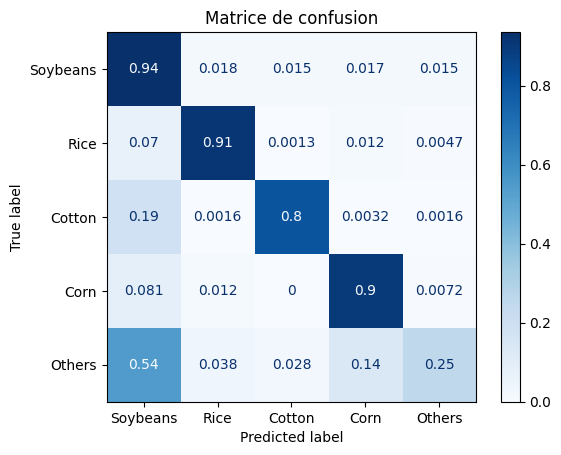

In [53]:
# Confusion Matrix 
labels = ["Soybeans", "Rice", "Cotton", "Corn", "Others"]
cm = confusion_matrix(y_test, y_a_pred,labels=[4,3,2,1,0])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm,display_labels=labels)
disp.plot(cmap="Blues")
plt.title("Matrice de confusion")
plt.show()

In [ ]:
#california
print(df_c.columns.tolist())


In [54]:
X_c = df_c.drop(columns=['crop_label','latitude','longitude','crop_name']).values

df_c_y = df_c[['crop_label']].copy()

keep = [3, 36, 69, 75, 204]

# tout le reste → 0
df_c_y['crop_label'] = df_c_y['crop_label'].apply(lambda x: x if x in keep else 0)

# remap
df_c_y['crop_label'] = df_c_y['crop_label'].replace({
    3: 1,
    36: 2,
    69: 3,
    75: 4,
    204: 5
})

y_c = df_c_y['crop_label'].values

print(sorted(np.unique(y_c)))

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [57]:
# =========================
# TIME SERIES
# =========================
X_time = df_c[[col for col in df_c.columns if '_T' in col]].values
X_time = X_time.reshape(-1, 36, 10)

# =========================
# TOPOGRAPHY
# =========================
X_static = df_c[['elevation', 'slope', 'aspect']].values
# =========================
# NORMALISATION TIME
# =========================
X_max = X_time.max(axis=(0, 1), keepdims=True)
X_max[X_max == 0] = 1  
X_time = X_time / X_max

# =========================
# NORMALISATION TOPO
# =========================
X_static = X_static / X_static.max(axis=0)

mask_time = (X_time != 0).astype(float)



In [58]:

X_time_train, X_time_test, \
X_static_train, X_static_test, \
y_train, y_test, \
mask_train, mask_test = train_test_split(
    X_time,
    X_static,
    y_c,
    mask_time,
    test_size=0.82,
    stratify=y_c,
    random_state=42
)

X_time_train, X_time_val, \
X_static_train, X_static_val, \
y_train, y_val, \
mask_train, mask_val = train_test_split(
    X_time_train,
    X_static_train,
    y_train,
    mask_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)


In [59]:
def build_MCTNet_c(input_shape=(36, 10), static_shape=(3,), num_classes=6):

    # =========================
    # INPUT TIME SERIES
    # =========================
    inputs = tf.keras.Input(shape=input_shape)
    mask = tf.keras.Input(shape=input_shape)

    x = ALPE(inputs, mask)

    x = CTFusion(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = CTFusion(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = CTFusion(x)

    x = layers.GlobalMaxPooling1D()(x)

    # =========================
    # TOPOGRAPHY (NEW ONLY)
    # =========================
    inputs_static = tf.keras.Input(shape=static_shape)

    x_static = layers.Dense(16, activation='relu')(inputs_static)

    # =========================
    # FUSION (MINIMAL CHANGE)
    # =========================
    x = layers.Concatenate()([x, x_static])

    # =========================
    # CLASSIFIER
    # =========================
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model_c = tf.keras.Model(
        inputs=[inputs, mask, inputs_static],
        outputs=outputs
    )

    return model_c


In [60]:
model_c = build_MCTNet_c()

model_c.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_c.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_14      │ (None, 36, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_15      │ (None, 36, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_13         │ (None, 36, 10)    │          0 │ input_layer_14[0… │
│ (Multiply)          │                   │            │ input_layer_15[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_29 (Conv1D)  │ (None, 36, 10)    │        310 │ multiply_13[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 10)        │          0 │ conv1d_29[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_49 (Dense)    │ (None, 10)        │        110 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_5 (Reshape) │ (None, 1, 10)     │          0 │ dense_49[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_14         │ (None, 36, 10)    │          0 │ conv1d_29[0][0],  │
│ (Multiply)          │                   │            │ reshape_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_30 (Conv1D)  │ (None, 36, 10)    │        310 │ multiply_14[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 36, 10)    │      2,160 │ multiply_14[0][0… │
│ (MultiHeadAttentio… │                   │            │ multiply_14[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 36, 10)    │         40 │ conv1d_30[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_37 (Add)        │ (None, 36, 10)    │          0 │ multiply_14[0][0… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_24 (ReLU)     │ (None, 36, 10)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 36, 10)    │         20 │ add_37[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_31 (Conv1D)  │ (None, 36, 10)    │        310 │ re_lu_24[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_50 (Dense)    │ (None, 36, 10)    │        110 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 36, 10)    │         40 │ conv1d_31[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_51 (Dense)    │ (None, 36, 10)    │        110 │ dense_50[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_36 (Add)        │ (None, 36, 10)    │          0 │ batch_normalizat… │
│                     │                   │            │ multiply_14[0][0] │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 10,636 (41.55 KB)

 Trainable params: 10,516 (41.08 KB)

 Non-trainable params: 120 (480.00 B)

In [61]:
model_c.fit(
    [X_time_train, mask_train, X_static_train],
    y_train,
    validation_data=([X_time_val, mask_val, X_static_val], y_val),
    epochs=200,
    batch_size=32
)


Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.3799 - loss: 1.5087 - val_accuracy: 0.2083 - val_loss: 1.8486
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4757 - loss: 1.3358 - val_accuracy: 0.1806 - val_loss: 1.7556
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5417 - loss: 1.2064 - val_accuracy: 0.2833 - val_loss: 1.6578
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5750 - loss: 1.1066 - val_accuracy: 0.2889 - val_loss: 1.8040
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6062 - loss: 1.0314 - val_accuracy: 0.2833 - val_loss: 1.8096
Epoch 6/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6222 - loss: 0.9897 - val_accuracy: 0.3472 - val_loss: 1.7653
Epoch 7/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6389 - loss: 0.9385 - val_accuracy: 0.2889 - val_loss: 1.7989
Epoch 8/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6646 - loss: 0.9010 - val_accuracy: 0

In [62]:
y_c_pred = model_c.predict([X_time_test, mask_test, X_static_test])
y_c_pred = y_c_pred.argmax(axis=1)

oa = accuracy_score(y_test, y_c_pred)
f1 = f1_score(y_test, y_c_pred, average='macro')
kappa = cohen_kappa_score(y_test, y_c_pred)

print("OA:", oa)
print("F1:", f1)
print("Kappa:", kappa)


257/257 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
OA: 0.6439024390243903
F1: 0.6478186597225092
Kappa: 0.5325984473304585


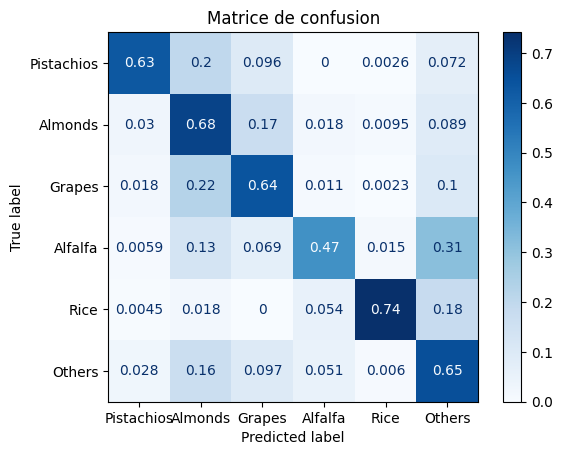

In [63]:
# Confusion Matrix 
labels = ["Pistachios","Almonds","Grapes", "Alfalfa","Rice", "Others"]
cm_c = confusion_matrix(y_test, y_c_pred,labels=[5,4,3,2,1,0])
cm_norm_c = cm_c.astype(float) / cm_c.sum(axis=1, keepdims=True)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm_c,display_labels=labels)
disp.plot(cmap="Blues")
plt.title("Matrice de confusion")
plt.show()